In [13]:
!head -n 3 mynewreport_modified.csv

App Name,Package Name,Country/Classification,Permissions,android.permission.READ_CONTACTS,android.permission.READ_CALL_LOG,android.permission.READ_EXTERNAL_STORAGE,android.permission.WRITE_EXTERNAL_STORAGE,android.permission.READ_MEDIA_AUDIO,android.permission.READ_MEDIA_IMAGES,android.permission.READ_MEDIA_VIDEO,android.permission.READ_SMS,android.permission.QUERY_ALL_PACKAGES,android.permission.ACCESS_FINE_LOCATION,ViolateGoogle,ViolateLoanWatch,ViolateCountryPolicy
M-Pawa,com.stima_mpawa,Kenya/Approved,"android.permission.CALL_PHONE, android.permission.INTERNET, android.permission.ACCESS_NETWORK_STATE",No,No,No,No,No,No,No,No,No,No,False,False,False
Ngao Credit,com.extrainch.ngaocredit,Kenya/Approved,"android.permission.WRITE_EXTERNAL_STORAGE, android.permission.RECORD_AUDIO, android.permission.WAKE_LOCK, android.permission.ACCESS_FINE_LOCATION, android.permission.POST_NOTIFICATIONS, android.permission.INTERNET, android.permission.CAMERA, android.permission.BLUETOOTH, android.permis

In [25]:
# Cell 1: Import libraries and define permission sets
import pandas as pd

# Define prohibited permissions
GOOGLE_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_CONTACTS', 'android.permission.ACCESS_FINE_LOCATION',
    'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_MEDIA_VIDEO',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.WRITE_EXTERNAL_STORAGE'
}

COUNTRY_PROHIBITED_PERMISSIONS = {
    'Indonesia': set(),
    'Kenya': {'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG'},
    'Nigeria': {
        'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
        'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES'
    },
    'Pakistan': {
        'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO',
        'android.permission.READ_CONTACTS', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_SMS'
    },
    'Philippines': {'android.permission.READ_CONTACTS'}
}

# Cell 2: Load the CSV
csv_file = 'mynewreport_modified.csv'
try:
    df = pd.read_csv(csv_file)
    print("CSV loaded successfully.")
except FileNotFoundError:
    print(f"Error: {csv_file} not found.")
    df = None
except Exception as e:
    print(f"Error loading CSV: {e}")
    df = None

# Cell 3: Function to parse permissions
def parse_permissions(permissions_str):
    if pd.isna(permissions_str):
        return set()
    return {perm.strip().strip('"').lower() for perm in permissions_str.split(',')}

# Cell 4: Function to check if permissions violate a prohibited set
def get_violating_permissions(app_permissions, prohibited_permissions):
    prohibited_permissions = {perm.lower() for perm in prohibited_permissions}
    return app_permissions.intersection(prohibited_permissions)

# Cell 5: Correct the discrepancies
if df is not None:
    # Correct MetaLoan (com.metaloan, Kenya/Approved): ViolateGoogle=True -> False
    meta_loan_mask = (df['Package Name'] == 'com.metaloan') & (df['Country/Classification'] == 'Kenya/Approved')
    if meta_loan_mask.any():
        df.loc[meta_loan_mask, 'ViolateGoogle'] = False
        print("Corrected ViolateGoogle for MetaLoan (com.metaloan, Kenya/Approved) to False")
    else:
        print("MetaLoan (com.metaloan, Kenya/Approved) not found in CSV")

    # Correct NewCash (com.perabag.app, Philippines/Delisted): ViolateCountryPolicy=True -> False
    new_cash_mask = (df['Package Name'] == 'com.perabag.app') & (df['Country/Classification'] == 'Philippines/Delisted')
    if new_cash_mask.any():
        df.loc[new_cash_mask, 'ViolateCountryPolicy'] = False
        print("Corrected ViolateCountryPolicy for NewCash (com.perabag.app, Philippines/Delisted) to False")
    else:
        print("NewCash (com.perabag.app, Philippines/Delisted) not found in CSV")

    # Validate corrections
    for _, row in df[meta_loan_mask | new_cash_mask].iterrows():
        app_permissions = parse_permissions(row['Permissions'])
        country = row['Country/Classification'].split('/')[0]
        country_prohibited = COUNTRY_PROHIBITED_PERMISSIONS.get(country, set())
        
        google_violates = bool(get_violating_permissions(app_permissions, GOOGLE_PROHIBITED_PERMISSIONS))
        country_violates = bool(get_violating_permissions(app_permissions, country_prohibited))
        
        print(f"\nValidation for {row['App Name']} ({row['Package Name']}, {row['Country/Classification']}):")
        print(f"  ViolateGoogle: {row['ViolateGoogle']}, Expected: {google_violates}")
        print(f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}, Expected: {country_violates}")
        if row['ViolateGoogle'] != google_violates:
            print(f"  Warning: ViolateGoogle still incorrect!")
        if row['ViolateCountryPolicy'] != country_violates:
            print(f"  Warning: ViolateCountryPolicy still incorrect!")
        print(f"  Permissions: {sorted(app_permissions)}")

    # Save the corrected CSV
    corrected_csv = 'mynewreport_modified_corrected.csv'
    df.to_csv(corrected_csv, index=False)
    print(f"\nCorrected CSV saved as {corrected_csv}")
else:
    print("Cannot proceed with corrections due to CSV loading error.")

CSV loaded successfully.
Corrected ViolateGoogle for MetaLoan (com.metaloan, Kenya/Approved) to False
Corrected ViolateCountryPolicy for NewCash (com.perabag.app, Philippines/Delisted) to False

Validation for MetaLoan (com.metaloan, Kenya/Approved):
  ViolateGoogle: False, Expected: False
  ViolateCountryPolicy: True, Expected: True
  Permissions: ['android.permission.access_coarse_location', 'android.permission.access_network_state', 'android.permission.access_wifi_state', 'android.permission.camera', 'android.permission.foreground_service', 'android.permission.get_accounts (maxsdkversion="22")', 'android.permission.get_package_size', 'android.permission.internet', 'android.permission.package_usage_stats', 'android.permission.post_notifications', 'android.permission.read_calendar', 'android.permission.read_call_log', 'android.permission.read_phone_state', 'android.permission.read_sms', 'android.permission.receive_boot_completed', 'android.permission.receive_sms', 'android.permission.

In [33]:
# Cell 1: Import pandas
import pandas as pd

# Cell 2: Load the CSV files
try:
    # Load mynewreport.csv to get the READ_PHONE_NUMBERS column
    df_source = pd.read_csv('mynewreport.csv')
    print("Loaded mynewreport.csv successfully.")
    
    # Load mynewreport_modified_corrected.csv to modify
    df_target = pd.read_csv('mynewreport_modified_corrected.csv')
    print("Loaded mynewreport_modified_corrected.csv successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    df_source = None
    df_target = None
except Exception as e:
    print(f"Error loading CSV: {e}")
    df_source = None
    df_target = None

# Cell 3: Validate and copy the column
if df_source is not None and df_target is not None:
    # Check if the required columns exist
    if 'android.permission.READ_PHONE_NUMBERS' not in df_source.columns:
        print("Error: 'android.permission.READ_PHONE_NUMBERS' column not found in mynewreport.csv")
    elif 'android.permission.READ_MEDIA_VIDEO' not in df_target.columns:
        print("Error: 'android.permission.READ_MEDIA_VIDEO' column not found in mynewreport_modified_corrected.csv")
    elif 'android.permission.READ_SMS' not in df_target.columns:
        print("Error: 'android.permission.READ_SMS' column not found in mynewreport_modified_corrected.csv")
    else:
        # Check if the number of rows match
        if len(df_source) != len(df_target):
            print(f"Error: Row count mismatch. mynewreport.csv has {len(df_source)} rows, "
                  f"mynewreport_modified_corrected.csv has {len(df_target)} rows")
        else:
            # Copy the READ_PHONE_NUMBERS column
            df_target['android.permission.READ_PHONE_NUMBERS'] = df_source['android.permission.READ_PHONE_NUMBERS']
            
            # Get the current column order
            columns = df_target.columns.tolist()
            
            # Find the index of READ_MEDIA_VIDEO
            video_index = columns.index('android.permission.READ_MEDIA_VIDEO')
            
            # Remove READ_PHONE_NUMBERS from its current position (appended at the end)
            columns.remove('android.permission.READ_PHONE_NUMBERS')
            
            # Insert READ_PHONE_NUMBERS after READ_MEDIA_VIDEO
            columns.insert(video_index + 1, 'android.permission.READ_PHONE_NUMBERS')
            
            # Reorder the DataFrame columns
            df_target = df_target[columns]
            
            # Save the modified DataFrame to a new CSV (or overwrite)
            output_file = 'mynewreport_modified_corrected_updated.csv'  # New file to avoid overwriting
            # Alternatively, use 'mynewreport_modified_corrected.csv' to overwrite
            df_target.to_csv(output_file, index=False)
            print(f"Modified CSV saved as {output_file}")
            
            # Verify the column order
            print("\nNew column order:")
            print(df_target.columns.tolist())
else:
    print("Cannot proceed due to CSV loading errors.")

Loaded mynewreport.csv successfully.
Loaded mynewreport_modified_corrected.csv successfully.
Modified CSV saved as mynewreport_modified_corrected_updated.csv

New column order:
['App Name', 'Package Name', 'Country/Classification', 'Permissions', 'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG', 'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.WRITE_EXTERNAL_STORAGE', 'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_SMS', 'android.permission.QUERY_ALL_PACKAGES', 'android.permission.ACCESS_FINE_LOCATION', 'ViolateGoogle', 'ViolateLoanWatch', 'ViolateCountryPolicy']


In [31]:
import pandas as pd

# Define prohibited permissions
COUNTRY_PROHIBITED_PERMISSIONS = {
    'Indonesia': set(),
    'Kenya': {'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG'},
    'Nigeria': {
        'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
        'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES'
    },
    'Pakistan': {
        'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO',
        'android.permission.READ_CONTACTS', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_SMS'
    },
    'Philippines': {'android.permission.READ_CONTACTS'}
}

GOOGLE_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_CONTACTS', 'android.permission.ACCESS_FINE_LOCATION',
    'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_MEDIA_VIDEO',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.WRITE_EXTERNAL_STORAGE'
}

LOANWATCH_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.WRITE_EXTERNAL_STORAGE',
    'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_SMS',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.ACCESS_FINE_LOCATION'
}

def load_csv(file_path):
    """Load the CSV file and return a DataFrame."""
    try:
        df = pd.read_csv(file_path)
        required_columns = ['App Name', 'Package Name', 'Country/Classification', 'Permissions',
                           'ViolateGoogle', 'ViolateLoanWatch', 'ViolateCountryPolicy']
        if not all(col in df.columns for col in required_columns):
            print(f"Error: CSV missing required columns. Found: {df.columns}")
            return None
        return df
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

def parse_permissions(permissions_str):
    """Parse the Permissions column into a set of permissions."""
    if pd.isna(permissions_str):
        return set()
    return {perm.strip().strip('"').lower() for perm in permissions_str.split(',')}

def get_violating_permissions(app_permissions, prohibited_permissions):
    """Return the permissions that violate the prohibited list."""
    prohibited_permissions = {perm.lower() for perm in prohibited_permissions}
    return app_permissions.intersection(prohibited_permissions)

def is_violation(value):
    """Check if a value indicates a violation (True/Yes/1, case-insensitive)."""
    if pd.isna(value):
        return False
    value = str(value).strip().lower()
    return value in ['true', 'yes', '1', 't', 'y']

def get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions):
    """Calculate permission-based and CSV-based violation counts by Country/Classification."""
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    counts = {
        'Perm_Country': {},
        'Perm_Google': {},
        'Perm_LoanWatch': {},
        'Perm_CountryNotGoogle': {},
        'Perm_LoanWatchNotCountry': {},
        'CSV_Country': {},
        'CSV_Google': {},
        'CSV_LoanWatch': {},
        'CSV_CountryNotGoogle': {},
        'Discrepancies': []
    }
    
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        
        # Initialize counts
        for key in counts:
            if key != 'Discrepancies':
                counts[key][country_class] = 0
        
        for _, row in country_df.iterrows():
            app_permissions = parse_permissions(row['Permissions'])
            app_name = row['App Name']
            package_name = row['Package Name']
            
            # Permission-based counts
            country_violates = bool(get_violating_permissions(app_permissions, country_prohibited))
            google_violates = bool(get_violating_permissions(app_permissions, google_permissions))
            loanwatch_violates = bool(get_violating_permissions(app_permissions, loanwatch_permissions))
            
            if country_violates:
                counts['Perm_Country'][country_class] += 1
            if google_violates:
                counts['Perm_Google'][country_class] += 1
            if loanwatch_violates:
                counts['Perm_LoanWatch'][country_class] += 1
            if country_violates and not google_violates:
                counts['Perm_CountryNotGoogle'][country_class] += 1
            if loanwatch_violates and not country_violates:
                counts['Perm_LoanWatchNotCountry'][country_class] += 1
            
            # CSV-based counts
            if is_violation(row['ViolateCountryPolicy']):
                counts['CSV_Country'][country_class] += 1
            if is_violation(row['ViolateGoogle']):
                counts['CSV_Google'][country_class] += 1
            if is_violation(row['ViolateLoanWatch']):
                counts['CSV_LoanWatch'][country_class] += 1
            if is_violation(row['ViolateCountryPolicy']) and not is_violation(row['ViolateGoogle']):
                counts['CSV_CountryNotGoogle'][country_class] += 1
            
            # Check for discrepancies
            if is_violation(row['ViolateCountryPolicy']) != country_violates:
                counts['Discrepancies'].append(
                    f"Country Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateCountryPolicy={row['ViolateCountryPolicy']}, Expected={country_violates}"
                )
            if is_violation(row['ViolateGoogle']) != google_violates:
                counts['Discrepancies'].append(
                    f"Google Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateGoogle={row['ViolateGoogle']}, Expected={google_violates}"
                )
            if is_violation(row['ViolateLoanWatch']) != loanwatch_violates:
                counts['Discrepancies'].append(
                    f"LoanWatch Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateLoanWatch={row['ViolateLoanWatch']}, Expected={loanwatch_violates}"
                )
    
    return counts

def save_counts(counts):
    """Save only the violation counts to violation_counts.txt."""
    with open('violation_counts.txt', 'w') as f:
        f.write("Violation Counts by Country/Classification:\n")
        for country_class in sorted(counts['Perm_Country'].keys()):
            f.write(f"\n{country_class}:\n")
            f.write(f"  Permission-Based Country Policy: {counts['Perm_Country'][country_class]}\n")
            f.write(f"  Permission-Based Google Policy: {counts['Perm_Google'][country_class]}\n")
            f.write(f"  Permission-Based LoanWatch Policy: {counts['Perm_LoanWatch'][country_class]}\n")
            f.write(f"  Permission-Based Country but Not Google: {counts['Perm_CountryNotGoogle'][country_class]}\n")
            f.write(f"  Permission-Based LoanWatch but Not Country: {counts['Perm_LoanWatchNotCountry'][country_class]}\n")
            f.write(f"  CSV ViolateCountryPolicy: {counts['CSV_Country'][country_class]}\n")
            f.write(f"  CSV ViolateGoogle: {counts['CSV_Google'][country_class]}\n")
            f.write(f"  CSV ViolateLoanWatch: {counts['CSV_LoanWatch'][country_class]}\n")
            f.write(f"  CSV Country but Not Google (ViolateCountryPolicy=True, ViolateGoogle=False): {counts['CSV_CountryNotGoogle'][country_class]}\n")
        f.write("\nTotal Discrepancies: {}\n".format(len(counts['Discrepancies'])))

def analyze_violations(df, country_permissions, google_permissions, loanwatch_permissions):
    """Analyze violations and return a detailed report."""
    report = []
    
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    # Debug info
    report.append("Debug Info:")
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        report.append(f"- {country_class}: {len(country_df)} apps")
        if not country_df.empty:
            sample_app = country_df.iloc[0]
            sample_perms = parse_permissions(sample_app['Permissions'])
            report.append(f"  Sample permissions: {', '.join(sorted(sample_perms))}")
    report.append("\n")
    
    # Get counts and discrepancies
    counts = get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions)
    
    # Save counts to separate file
    save_counts(counts)
    
    # Detailed violation analysis
    for country_class in sorted(df['Country/Classification'].unique()):
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        country_df = df[df['Country/Classification'] == country_class]
        
        report.append(f"Country/Classification: {country_class}\n")
        
        # Country Policy Violations
        if country_prohibited:
            country_violators = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), country_prohibited))
                )
            ]
            
            report.append("Apps Violating Country Policy:\n")
            report.append(f"Total: {len(country_violators)}\n")
            if not country_violators.empty:
                for _, row in country_violators.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        else:
            report.append("No country-specific prohibited permissions defined.\n")
        
        # Google Policy Violations
        google_violators = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), google_permissions))
            )
        ]
        
        report.append("\nApps Violating Google Policy:\n")
        report.append(f"Total: {len(google_violators)}\n")
        if not google_violators.empty:
            for _, row in google_violators.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, google_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
        
        # LoanWatch Policy Violations
        loanwatch_violators = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions))
            )
        ]
        
        report.append("\nApps Violating LoanWatch Policy:\n")
        report.append(f"Total: {len(loanwatch_violators)}\n")
        if not loanwatch_violators.empty:
            for _, row in loanwatch_violators.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
        
        # Country but Not Google
        if country_prohibited:
            country_not_google = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), country_prohibited)) and
                    not get_violating_permissions(parse_permissions(x), google_permissions)
                )
            ]
            
            report.append("\nApps Violating Country Policy but Not Google's Policy:\n")
            report.append(f"Total: {len(country_not_google)}\n")
            if not country_not_google.empty:
                for _, row in country_not_google.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        
        # LoanWatch but Not Country
        loanwatch_not_country = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions)) and
                not get_violating_permissions(parse_permissions(x), country_prohibited)
            )
        ]
        
        report.append("\nApps Violating LoanWatch but Not Country Policy:\n")
        report.append(f"Total: {len(loanwatch_not_country)}\n")
        if not loanwatch_not_country.empty:
            for _, row in loanwatch_not_country.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                    f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
    
    # Report discrepancies
    report.append("\nDiscrepancies (Violate* vs. Permissions):")
    if counts['Discrepancies']:
        report.extend([f"- {d}" for d in counts['Discrepancies'][:10]])
        if len(counts['Discrepancies']) > 10:
            report.append(f"... {len(counts['Discrepancies']) - 10} more discrepancies")
    else:
        report.append("- None")
    
    return "\n".join(report)

def main():
    file_path = 'mynewreport_modified_corrected.csv'
    df = load_csv(file_path)
    if df is None:
        return
    
    # Generate detailed report
    report = analyze_violations(
        df, COUNTRY_PROHIBITED_PERMISSIONS, GOOGLE_PROHIBITED_PERMISSIONS, LOANWATCH_PROHIBITED_PERMISSIONS
    )
    
    # Save detailed report
    output_file = 'newapp_violations_report.txt'
    with open(output_file, 'w') as f:
        f.write(report)
    print(f"Detailed report generated: {output_file}")

if __name__ == '__main__':
    main()

Detailed report generated: newapp_violations_report.txt


In [35]:
import pandas as pd

# Define prohibited permissions
COUNTRY_PROHIBITED_PERMISSIONS = {
    'Indonesia': set(),
    'Kenya': {'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG'},
    'Nigeria': {
        'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
        'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES'
    },
    'Pakistan': {
        'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO',
        'android.permission.READ_CONTACTS', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_SMS'
    },
    'Philippines': {'android.permission.READ_CONTACTS'}
}

GOOGLE_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_CONTACTS', 'android.permission.ACCESS_FINE_LOCATION',
    'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_MEDIA_VIDEO',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.WRITE_EXTERNAL_STORAGE'
}

LOANWATCH_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.WRITE_EXTERNAL_STORAGE',
    'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_SMS',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.ACCESS_FINE_LOCATION'
}

def load_csv(file_path):
    """Load the CSV file and return a DataFrame."""
    try:
        df = pd.read_csv(file_path)
        required_columns = ['App Name', 'Package Name', 'Country/Classification', 'Permissions',
                           'ViolateGoogle', 'ViolateLoanWatch', 'ViolateCountryPolicy']
        if not all(col in df.columns for col in required_columns):
            print(f"Error: CSV missing required columns. Found: {df.columns}")
            return None
        return df
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

def parse_permissions(permissions_str):
    """Parse the Permissions column into a set of permissions."""
    if pd.isna(permissions_str):
        return set()
    return {perm.strip().strip('"').lower() for perm in permissions_str.split(',')}

def get_violating_permissions(app_permissions, prohibited_permissions):
    """Return the permissions that violate the prohibited list."""
    prohibited_permissions = {perm.lower() for perm in prohibited_permissions}
    return app_permissions.intersection(prohibited_permissions)

def is_violation(value):
    """Check if a value indicates a violation (True/Yes/1, case-insensitive)."""
    if pd.isna(value):
        return False
    value = str(value).strip().lower()
    return value in ['true', 'yes', '1', 't', 'y']

def get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions):
    """Calculate permission-based and CSV-based violation counts by Country/Classification."""
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    counts = {
        'Perm_Country': {},
        'Perm_Google': {},
        'Perm_LoanWatch': {},
        'Perm_CountryNotGoogle': {},
        'Perm_GoogleNotCountry': {},
        'Perm_LoanWatchNotCountry': {},
        'Perm_LoanWatchNotGoogle': {},
        'CSV_Country': {},
        'CSV_Google': {},
        'CSV_LoanWatch': {},
        'CSV_CountryNotGoogle': {},
        'CountryNotGoogle_Perms': {},  # Track permissions for Country but Not Google
        'GoogleNotCountry_Perms': {},  # Track permissions for Google but Not Country
        'LoanWatchNotCountry_Perms': {},  # Track permissions for LoanWatch but Not Country
        'LoanWatchNotGoogle_Perms': {},  # Track permissions for LoanWatch but Not Google
        'Discrepancies': []
    }
    
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        
        # Initialize counts
        for key in counts:
            if key not in ['Discrepancies', 'CountryNotGoogle_Perms', 'GoogleNotCountry_Perms',
                          'LoanWatchNotCountry_Perms', 'LoanWatchNotGoogle_Perms']:
                counts[key][country_class] = 0
        counts['CountryNotGoogle_Perms'][country_class] = {}
        counts['GoogleNotCountry_Perms'][country_class] = {}
        counts['LoanWatchNotCountry_Perms'][country_class] = {}
        counts['LoanWatchNotGoogle_Perms'][country_class] = {}
        
        for _, row in country_df.iterrows():
            app_permissions = parse_permissions(row['Permissions'])
            app_name = row['App Name']
            package_name = row['Package Name']
            
            # Permission-based counts
            country_violates = bool(get_violating_permissions(app_permissions, country_prohibited))
            google_violates = bool(get_violating_permissions(app_permissions, google_permissions))
            loanwatch_violates = bool(get_violating_permissions(app_permissions, loanwatch_permissions))
            
            if country_violates:
                counts['Perm_Country'][country_class] += 1
            if google_violates:
                counts['Perm_Google'][country_class] += 1
            if loanwatch_violates:
                counts['Perm_LoanWatch'][country_class] += 1
            
            # Country but Not Google
            if country_violates and not google_violates:
                counts['Perm_CountryNotGoogle'][country_class] += 1
                violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                for perm in violating_perms:
                    perm_short = perm.split('.')[-1]
                    counts['CountryNotGoogle_Perms'][country_class][perm_short] = \
                        counts['CountryNotGoogle_Perms'][country_class].get(perm_short, 0) + 1
            
            # Google but Not Country
            if google_violates and not country_violates:
                counts['Perm_GoogleNotCountry'][country_class] += 1
                violating_perms = get_violating_permissions(app_permissions, google_permissions)
                for perm in violating_perms:
                    perm_short = perm.split('.')[-1]
                    counts['GoogleNotCountry_Perms'][country_class][perm_short] = \
                        counts['GoogleNotCountry_Perms'][country_class].get(perm_short, 0) + 1
            
            # LoanWatch but Not Country
            if loanwatch_violates and not country_violates:
                counts['Perm_LoanWatchNotCountry'][country_class] += 1
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                for perm in violating_perms:
                    perm_short = perm.split('.')[-1]
                    counts['LoanWatchNotCountry_Perms'][country_class][perm_short] = \
                        counts['LoanWatchNotCountry_Perms'][country_class].get(perm_short, 0) + 1
            
            # LoanWatch but Not Google
            if loanwatch_violates and not google_violates:
                counts['Perm_LoanWatchNotGoogle'][country_class] += 1
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                for perm in violating_perms:
                    perm_short = perm.split('.')[-1]
                    counts['LoanWatchNotGoogle_Perms'][country_class][perm_short] = \
                        counts['LoanWatchNotGoogle_Perms'][country_class].get(perm_short, 0) + 1
            
            # CSV-based counts
            if is_violation(row['ViolateCountryPolicy']):
                counts['CSV_Country'][country_class] += 1
            if is_violation(row['ViolateGoogle']):
                counts['CSV_Google'][country_class] += 1
            if is_violation(row['ViolateLoanWatch']):
                counts['CSV_LoanWatch'][country_class] += 1
            if is_violation(row['ViolateCountryPolicy']) and not is_violation(row['ViolateGoogle']):
                counts['CSV_CountryNotGoogle'][country_class] += 1
            
            # Check for discrepancies
            if is_violation(row['ViolateCountryPolicy']) != country_violates:
                counts['Discrepancies'].append(
                    f"Country Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateCountryPolicy={row['ViolateCountryPolicy']}, Expected={country_violates}"
                )
            if is_violation(row['ViolateGoogle']) != google_violates:
                counts['Discrepancies'].append(
                    f"Google Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateGoogle={row['ViolateGoogle']}, Expected={google_violates}"
                )
            if is_violation(row['ViolateLoanWatch']) != loanwatch_violates:
                counts['Discrepancies'].append(
                    f"LoanWatch Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateLoanWatch={row['ViolateLoanWatch']}, Expected={loanwatch_violates}"
                )
    
    return counts

def save_counts(counts):
    """Save violation counts to violation_counts.txt with permission details."""
    with open('violation_counts.txt', 'w') as f:
        f.write("Violation Counts by Country/Classification:\n")
        for country_class in sorted(counts['Perm_Country'].keys()):
            f.write(f"\n{country_class}:\n")
            f.write(f"  Permission-Based Country Policy: {counts['Perm_Country'][country_class]}\n")
            f.write(f"  Permission-Based Google Policy: {counts['Perm_Google'][country_class]}\n")
            f.write(f"  Permission-Based LoanWatch Policy: {counts['Perm_LoanWatch'][country_class]}\n")
            
            # Country but Not Google with permissions
            country_not_google_count = counts['Perm_CountryNotGoogle'][country_class]
            country_not_google_perms = counts['CountryNotGoogle_Perms'][country_class]
            perm_details = ", ".join(
                f"{perm} = {count}" for perm, count in sorted(country_not_google_perms.items())
            ) if country_not_google_perms else "None"
            f.write(f"  Permission-Based Country but Not Google: {country_not_google_count} "
                    f"({perm_details})\n")
            
            # Google but Not Country with permissions
            google_not_country_count = counts['Perm_GoogleNotCountry'][country_class]
            google_not_country_perms = counts['GoogleNotCountry_Perms'][country_class]
            perm_details = ", ".join(
                f"{perm} = {count}" for perm, count in sorted(google_not_country_perms.items())
            ) if google_not_country_perms else "None"
            f.write(f"  Permission-Based Google but Not Country: {google_not_country_count} "
                    f"({perm_details})\n")
            
            # LoanWatch but Not Country with permissions
            loanwatch_not_country_count = counts['Perm_LoanWatchNotCountry'][country_class]
            loanwatch_not_country_perms = counts['LoanWatchNotCountry_Perms'][country_class]
            perm_details = ", ".join(
                f"{perm} = {count}" for perm, count in sorted(loanwatch_not_country_perms.items())
            ) if loanwatch_not_country_perms else "None"
            f.write(f"  Permission-Based LoanWatch but Not Country: {loanwatch_not_country_count} "
                    f"({perm_details})\n")
            
            # LoanWatch but Not Google with permissions
            loanwatch_not_google_count = counts['Perm_LoanWatchNotGoogle'][country_class]
            loanwatch_not_google_perms = counts['LoanWatchNotGoogle_Perms'][country_class]
            perm_details = ", ".join(
                f"{perm} = {count}" for perm, count in sorted(loanwatch_not_google_perms.items())
            ) if loanwatch_not_google_perms else "None"
            f.write(f"  Permission-Based LoanWatch but Not Google: {loanwatch_not_google_count} "
                    f"({perm_details})\n")
            
            f.write(f"  CSV ViolateCountryPolicy: {counts['CSV_Country'][country_class]}\n")
            f.write(f"  CSV ViolateGoogle: {counts['CSV_Google'][country_class]}\n")
            f.write(f"  CSV ViolateLoanWatch: {counts['CSV_LoanWatch'][country_class]}\n")
            f.write(f"  CSV Country but Not Google (ViolateCountryPolicy=True, ViolateGoogle=False): "
                    f"{counts['CSV_CountryNotGoogle'][country_class]}\n")
        f.write("\nTotal Discrepancies: {}\n".format(len(counts['Discrepancies'])))

def analyze_violations(df, country_permissions, google_permissions, loanwatch_permissions):
    """Analyze violations and return a detailed report."""
    report = []
    
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    # Debug info
    report.append("Debug Info:")
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        report.append(f"- {country_class}: {len(country_df)} apps")
        if not country_df.empty:
            sample_app = country_df.iloc[0]
            sample_perms = parse_permissions(sample_app['Permissions'])
            report.append(f"  Sample permissions: {', '.join(sorted(sample_perms))}")
    report.append("\n")
    
    # Get counts and discrepancies
    counts = get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions)
    
    # Save counts to separate file
    save_counts(counts)
    
    # Detailed violation analysis
    for country_class in sorted(df['Country/Classification'].unique()):
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        country_df = df[df['Country/Classification'] == country_class]
        
        report.append(f"Country/Classification: {country_class}\n")
        
        # Country Policy Violations
        if country_prohibited:
            country_violators = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), country_prohibited))
                )
            ]
            
            report.append("Apps Violating Country Policy:\n")
            report.append(f"Total: {len(country_violators)}\n")
            if not country_violators.empty:
                for _, row in country_violators.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        else:
            report.append("No country-specific prohibited permissions defined.\n")
        
        # Google Policy Violations
        google_violators = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), google_permissions))
            )
        ]
        
        report.append("\nApps Violating Google Policy:\n")
        report.append(f"Total: {len(google_violators)}\n")
        if not google_violators.empty:
            for _, row in google_violators.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, google_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
        
        # Google but Not Country
        if country_prohibited:
            google_not_country = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), google_permissions)) and
                    not get_violating_permissions(parse_permissions(x), country_prohibited)
                )
            ]
            
            report.append("\nApps Violating Google Policy but Not Country Policy:\n")
            report.append(f"Total: {len(google_not_country)}\n")
            if not google_not_country.empty:
                for _, row in google_not_country.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, google_permissions)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        
        # LoanWatch Policy Violations
        loanwatch_violators = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions))
            )
        ]
        
        report.append("\nApps Violating LoanWatch Policy:\n")
        report.append(f"Total: {len(loanwatch_violators)}\n")
        if not loanwatch_violators.empty:
            for _, row in loanwatch_violators.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
        
        # Country but Not Google
        if country_prohibited:
            country_not_google = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), country_prohibited)) and
                    not get_violating_permissions(parse_permissions(x), google_permissions)
                )
            ]
            
            report.append("\nApps Violating Country Policy but Not Google's Policy:\n")
            report.append(f"Total: {len(country_not_google)}\n")
            if not country_not_google.empty:
                for _, row in country_not_google.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        
        # LoanWatch but Not Country
        if country_prohibited:
            loanwatch_not_country = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions)) and
                    not get_violating_permissions(parse_permissions(x), country_prohibited)
                )
            ]
            
            report.append("\nApps Violating LoanWatch but Not Country Policy:\n")
            report.append(f"Total: {len(loanwatch_not_country)}\n")
            if not loanwatch_not_country.empty:
                for _, row in loanwatch_not_country.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        
        # LoanWatch but Not Google
        loanwatch_not_google = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions)) and
                not get_violating_permissions(parse_permissions(x), google_permissions)
            )
        ]
        
        report.append("\nApps Violating LoanWatch but Not Google Policy:\n")
        report.append(f"Total: {len(loanwatch_not_google)}\n")
        if not loanwatch_not_google.empty:
            for _, row in loanwatch_not_google.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                    f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
    
    # Report discrepancies
    report.append("\nDiscrepancies (Violate* vs. Permissions):")
    if counts['Discrepancies']:
        report.extend([f"- {d}" for d in counts['Discrepancies'][:10]])
        if len(counts['Discrepancies']) > 10:
            report.append(f"... {len(counts['Discrepancies']) - 10} more discrepancies")
    else:
        report.append("- None")
    
    return "\n".join(report)

def main():
    file_path = 'mynewreport_modified_corrected_updated.csv'
    df = load_csv(file_path)
    if df is None:
        return
    
    # Generate detailed report
    report = analyze_violations(
        df, COUNTRY_PROHIBITED_PERMISSIONS, GOOGLE_PROHIBITED_PERMISSIONS, LOANWATCH_PROHIBITED_PERMISSIONS
    )
    
    # Save detailed report
    output_file = 'updatedcurrentapp_violations_report.txt'
    with open(output_file, 'w') as f:
        f.write(report)
    print(f"Detailed report generated: {output_file}")

if __name__ == '__main__':
    main()

Detailed report generated: updatedcurrentapp_violations_report.txt


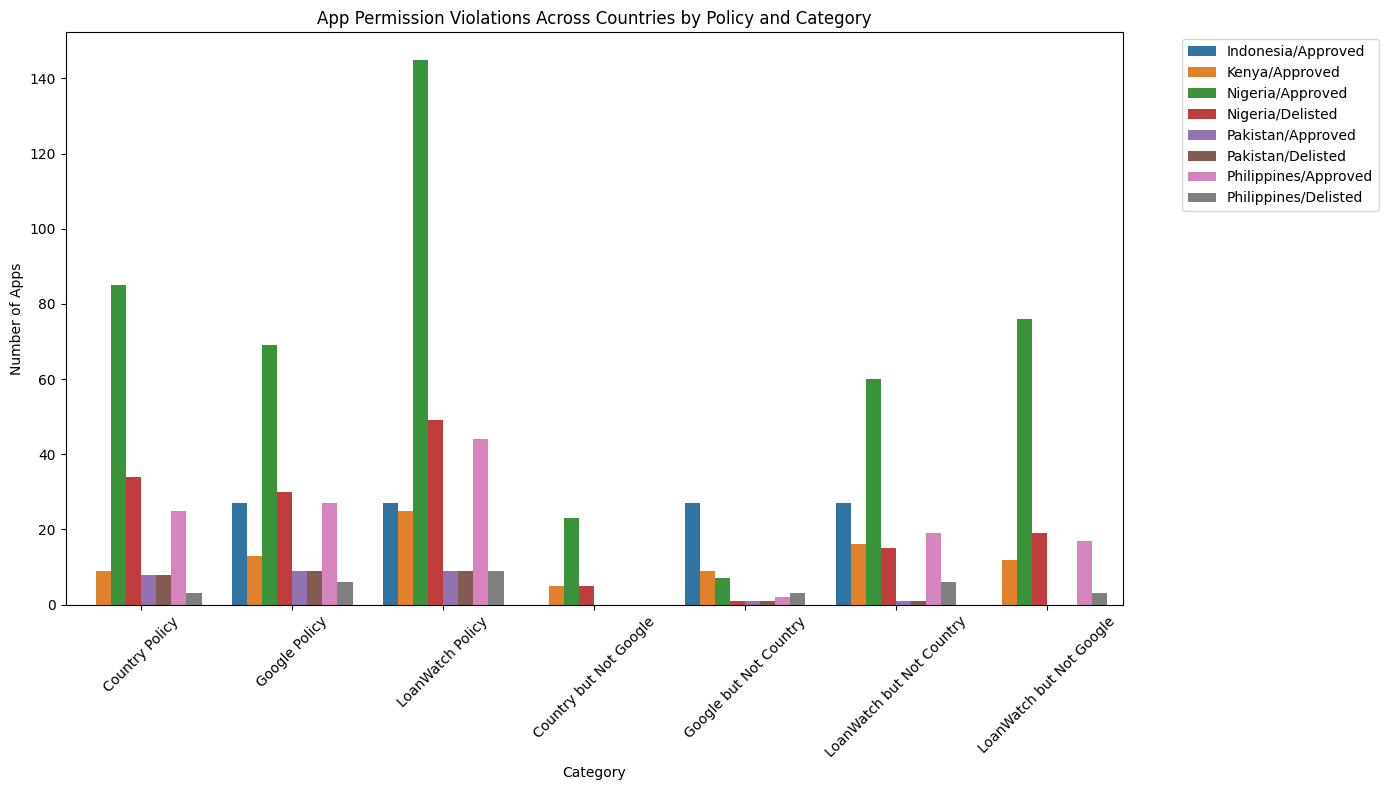

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from Table 1
data = {
    'Category': ['Country Policy', 'Google Policy', 'LoanWatch Policy', 
                 'Country but Not Google', 'Google but Not Country', 
                 'LoanWatch but Not Country', 'LoanWatch but Not Google'] * 8,
    'Classification': ['Indonesia/Approved']*7 + ['Kenya/Approved']*7 + 
                      ['Nigeria/Approved']*7 + ['Nigeria/Delisted']*7 + 
                      ['Pakistan/Approved']*7 + ['Pakistan/Delisted']*7 + 
                      ['Philippines/Approved']*7 + ['Philippines/Delisted']*7,
    'Apps': [0, 27, 27, 0, 27, 27, 0,  # Indonesia/Approved
             9, 13, 25, 5, 9, 16, 12,  # Kenya/Approved
             85, 69, 145, 23, 7, 60, 76,  # Nigeria/Approved
             34, 30, 49, 5, 1, 15, 19,  # Nigeria/Delisted
             8, 9, 9, 0, 1, 1, 0,  # Pakistan/Approved
             8, 9, 9, 0, 1, 1, 0,  # Pakistan/Delisted
             25, 27, 44, 0, 2, 19, 17,  # Philippines/Approved
             3, 6, 9, 0, 3, 6, 3]  # Philippines/Delisted
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Category', y='Apps', hue='Classification', data=df)
plt.title('App Permission Violations Across Countries by Policy and Category')
plt.xticks(rotation=45)
plt.ylabel('Number of Apps')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('all_countries_violation_counts.png')
plt.show()

In [30]:
import pandas as pd

# Define prohibited permissions
COUNTRY_PROHIBITED_PERMISSIONS = {
    'Indonesia': set(),
    'Kenya': {'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG'},
    'Nigeria': {
        'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
        'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES'
    },
    'Pakistan': {
        'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO',
        'android.permission.READ_CONTACTS', 'android.permission.READ_EXTERNAL_STORAGE',
        'android.permission.READ_SMS'
    },
    'Philippines': {'android.permission.READ_CONTACTS'}
}

GOOGLE_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_CONTACTS', 'android.permission.ACCESS_FINE_LOCATION',
    'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_MEDIA_VIDEO',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.WRITE_EXTERNAL_STORAGE'
}

LOANWATCH_PROHIBITED_PERMISSIONS = {
    'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG',
    'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.WRITE_EXTERNAL_STORAGE',
    'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES',
    'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_SMS',
    'android.permission.QUERY_ALL_PACKAGES', 'android.permission.ACCESS_FINE_LOCATION'
}

def load_csv(file_path):
    """Load the CSV file and return a DataFrame."""
    try:
        df = pd.read_csv(file_path)
        required_columns = ['App Name', 'Package Name', 'Country/Classification', 'Permissions',
                           'ViolateGoogle', 'ViolateLoanWatch', 'ViolateCountryPolicy']
        if not all(col in df.columns for col in required_columns):
            print(f"Error: CSV missing required columns. Found: {df.columns}")
            return None
        return df
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

def parse_permissions(permissions_str):
    """Parse the Permissions column into a set of permissions."""
    if pd.isna(permissions_str):
        return set()
    return {perm.strip().strip('"').lower() for perm in permissions_str.split(',')}

def get_violating_permissions(app_permissions, prohibited_permissions):
    """Return the permissions that violate the prohibited list."""
    prohibited_permissions = {perm.lower() for perm in prohibited_permissions}
    return app_permissions.intersection(prohibited_permissions)

def is_violation(value):
    """Check if a value indicates a violation (True/Yes/1, case-insensitive)."""
    if pd.isna(value):
        return False
    value = str(value).strip().lower()
    return value in ['true', 'yes', '1', 't', 'y']

def get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions):
    """Calculate CSV-based and permission-based violation counts by Country/Classification."""
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    counts = {
        'CSV_ViolateCountry': {},
        'CSV_ViolateGoogle': {},
        'CSV_ViolateLoanWatch': {},
        'CSV_CountryNotGoogle': {},
        'Perm_CountryNotGoogle': {},
        'Perm_LoanWatchNotCountry': {},
        'Discrepancies': []
    }
    
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        
        # Initialize counts
        counts['CSV_ViolateCountry'][country_class] = 0
        counts['CSV_ViolateGoogle'][country_class] = 0
        counts['CSV_ViolateLoanWatch'][country_class] = 0
        counts['CSV_CountryNotGoogle'][country_class] = 0
        counts['Perm_CountryNotGoogle'][country_class] = 0
        counts['Perm_LoanWatchNotCountry'][country_class] = 0
        
        for _, row in country_df.iterrows():
            app_permissions = parse_permissions(row['Permissions'])
            app_name = row['App Name']
            package_name = row['Package Name']
            
            # CSV-based counts
            if is_violation(row['ViolateCountryPolicy']):
                counts['CSV_ViolateCountry'][country_class] += 1
            if is_violation(row['ViolateGoogle']):
                counts['CSV_ViolateGoogle'][country_class] += 1
            if is_violation(row['ViolateLoanWatch']):
                counts['CSV_ViolateLoanWatch'][country_class] += 1
            if is_violation(row['ViolateCountryPolicy']) and not is_violation(row['ViolateGoogle']):
                counts['CSV_CountryNotGoogle'][country_class] += 1
            
            # Permission-based counts
            country_violates = bool(get_violating_permissions(app_permissions, country_prohibited))
            google_violates = bool(get_violating_permissions(app_permissions, google_permissions))
            loanwatch_violates = bool(get_violating_permissions(app_permissions, loanwatch_permissions))
            
            if country_violates and not google_violates:
                counts['Perm_CountryNotGoogle'][country_class] += 1
            if loanwatch_violates and not country_violates:
                counts['Perm_LoanWatchNotCountry'][country_class] += 1
            
            # Check for discrepancies
            if is_violation(row['ViolateCountryPolicy']) != country_violates:
                counts['Discrepancies'].append(
                    f"Country Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateCountryPolicy={row['ViolateCountryPolicy']}, Expected={country_violates}"
                )
            if is_violation(row['ViolateGoogle']) != google_violates:
                counts['Discrepancies'].append(
                    f"Google Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateGoogle={row['ViolateGoogle']}, Expected={google_violates}"
                )
            if is_violation(row['ViolateLoanWatch']) != loanwatch_violates:
                counts['Discrepancies'].append(
                    f"LoanWatch Violation Mismatch: {app_name} ({package_name}, {country_class}): "
                    f"ViolateLoanWatch={row['ViolateLoanWatch']}, Expected={loanwatch_violates}"
                )
    
    return counts

def save_counts(counts):
    """Save only the violation counts to violation_counts.txt."""
    with open('violation_counts.txt', 'w') as f:
        f.write("Violation Counts by Country/Classification:\n")
        for country_class in sorted(counts['CSV_ViolateCountry'].keys()):
            f.write(f"\n{country_class}:\n")
            f.write(f"  CSV ViolateCountryPolicy: {counts['CSV_ViolateCountry'][country_class]}\n")
            f.write(f"  CSV ViolateGoogle: {counts['CSV_ViolateGoogle'][country_class]}\n")
            f.write(f"  CSV ViolateLoanWatch: {counts['CSV_ViolateLoanWatch'][country_class]}\n")
            f.write(f"  CSV Country but Not Google (ViolateCountryPolicy=True, ViolateGoogle=False): {counts['CSV_CountryNotGoogle'][country_class]}\n")
            f.write(f"  Permission-Based Country but Not Google: {counts['Perm_CountryNotGoogle'][country_class]}\n")
            f.write(f"  Permission-Based LoanWatch but Not Country: {counts['Perm_LoanWatchNotCountry'][country_class]}\n")
        f.write("\nTotal Discrepancies: {}\n".format(len(counts['Discrepancies'])))

def analyze_violations(df, country_permissions, google_permissions, loanwatch_permissions):
    """Analyze violations and return a detailed report."""
    report = []
    
    country_permissions = {k: {p.lower() for p in v} for k, v in country_permissions.items()}
    google_permissions = {p.lower() for p in google_permissions}
    loanwatch_permissions = {p.lower() for p in loanwatch_permissions}
    
    # Debug info
    report.append("Debug Info:")
    for country_class in sorted(df['Country/Classification'].unique()):
        country_df = df[df['Country/Classification'] == country_class]
        report.append(f"- {country_class}: {len(country_df)} apps")
        if not country_df.empty:
            sample_app = country_df.iloc[0]
            sample_perms = parse_permissions(sample_app['Permissions'])
            report.append(f"  Sample permissions: {', '.join(sorted(sample_perms))}")
    report.append("\n")
    
    # Get counts and discrepancies
    counts = get_violation_counts(df, country_permissions, google_permissions, loanwatch_permissions)
    
    # Save counts to separate file
    save_counts(counts)
    
    # Detailed violation analysis
    for country_class in sorted(df['Country/Classification'].unique()):
        country = country_class.split('/')[0]
        country_prohibited = country_permissions.get(country, set())
        country_df = df[df['Country/Classification'] == country_class]
        
        report.append(f"Country/Classification: {country_class}\n")
        
        # Part 1: Apps violating country policy but not Google's policy
        if country_prohibited:
            country_not_google = country_df[
                country_df['Permissions'].apply(
                    lambda x: bool(get_violating_permissions(parse_permissions(x), country_prohibited)) and
                    not get_violating_permissions(parse_permissions(x), google_permissions)
                )
            ]
            
            report.append("Apps Violating Country Policy but Not Google's Policy:\n")
            report.append(f"Total: {len(country_not_google)}\n")
            if not country_not_google.empty:
                for _, row in country_not_google.iterrows():
                    app_permissions = parse_permissions(row['Permissions'])
                    violating_perms = get_violating_permissions(app_permissions, country_prohibited)
                    report.append(
                        f"- App Name: {row['App Name']}\n"
                        f"  Package Name: {row['Package Name']}\n"
                        f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                        f"  ViolateGoogle: {row['ViolateGoogle']}\n"
                        f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                        f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                    )
            else:
                report.append("  None\n")
        else:
            report.append("No country-specific prohibited permissions defined.\n")
        
        # Part 2: Apps violating LoanWatch but not country policy
        loanwatch_not_country = country_df[
            country_df['Permissions'].apply(
                lambda x: bool(get_violating_permissions(parse_permissions(x), loanwatch_permissions)) and
                not get_violating_permissions(parse_permissions(x), country_prohibited)
            )
        ]
        
        report.append("\nApps Violating LoanWatch but Not Country Policy:\n")
        report.append(f"Total: {len(loanwatch_not_country)}\n")
        if not loanwatch_not_country.empty:
            for _, row in loanwatch_not_country.iterrows():
                app_permissions = parse_permissions(row['Permissions'])
                violating_perms = get_violating_permissions(app_permissions, loanwatch_permissions)
                report.append(
                    f"- App Name: {row['App Name']}\n"
                    f"  Package Name: {row['Package Name']}\n"
                    f"  ViolateLoanWatch: {row['ViolateLoanWatch']}\n"
                    f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}\n"
                    f"  Permissions: {', '.join(sorted(app_permissions))}\n"
                    f"  Violating Permissions: {', '.join(sorted(violating_perms))}\n"
                )
        else:
            report.append("  None\n")
    
    # Report discrepancies
    report.append("\nDiscrepancies (Violate* vs. Permissions):")
    if counts['Discrepancies']:
        report.extend([f"- {d}" for d in counts['Discrepancies'][:10]])
        if len(counts['Discrepancies']) > 10:
            report.append(f"... {len(counts['Discrepancies']) - 10} more discrepancies")
    else:
        report.append("- None")
    
    return "\n".join(report)

def main():
    file_path = 'mynewreport_modified_corrected.csv'
    df = load_csv(file_path)
    if df is None:
        return
    
    # Generate detailed report
    report = analyze_violations(
        df, COUNTRY_PROHIBITED_PERMISSIONS, GOOGLE_PROHIBITED_PERMISSIONS, LOANWATCH_PROHIBITED_PERMISSIONS
    )
    
    # Save detailed report
    output_file = 'app_violations_report.txt'
    with open(output_file, 'w') as f:
        f.write(report)
    print(f"Detailed report generated: {output_file}")

if __name__ == '__main__':
    main()

Detailed report generated: app_violations_report.txt


In [9]:
import pandas as pd
import os

# Define the input and output CSV file paths
input_csv = 'mynewreport.csv'
output_csv = 'mynewreport_modified.csv'

# List of columns to remove (exact names from your CSV)
columns_to_remove = [
    'android.permission.WRITE_CALL_LOG',
    'android.permission.MANAGE_EXTERNAL_STORAGE',
    'android.permission.MANAGE_MEDIA',
    'android.permission.READ_PHONE_NUMBERS',
    'Has Restricted Permission',
    'android.permission.MANAGE_ONGOING_CALLS'
]

try:
    # Verify that the input file exists
    if not os.path.exists(input_csv):
        raise FileNotFoundError(f"The file {input_csv} was not found in the current directory: {os.getcwd()}")

    # Read the CSV file
    df = pd.read_csv(input_csv, encoding='utf-8')

    # Print all column names for debugging
    print("Column names in the CSV:")
    for col in df.columns:
        print(f"- '{col}'")

    # Check for exact matches and potential mismatches
    missing_columns = [col for col in columns_to_remove if col not in df.columns]
    if missing_columns:
        print(f"Warning: The following columns were not found in the CSV: {missing_columns}")
        print("Please verify the column names above for any discrepancies (e.g., spaces, case sensitivity).")

    # Drop the specified columns
    df = df.drop(columns=columns_to_remove, errors='ignore')

    # Save the modified DataFrame to a new CSV file
    df.to_csv(output_csv, index=False)
    print(f"Successfully removed columns and saved to {output_csv}")

except FileNotFoundError as e:
    print(f"Error: {e}")
except UnicodeDecodeError:
    print("Error: The CSV file could not be read with UTF-8 encoding. Trying 'latin1' encoding...")
    try:
        df = pd.read_csv(input_csv, encoding='latin1')
        print("Column names in the CSV (latin1 encoding):")
        for col in df.columns:
            print(f"- '{col}'")
        missing_columns = [col for col in columns_to_remove if col not in df.columns]
        if missing_columns:
            print(f"Warning: The following columns were not found in the CSV: {missing_columns}")
        df = df.drop(columns=columns_to_remove, errors='ignore')
        df.to_csv(output_csv, index=False)
        print(f"Successfully removed columns and saved to {output_csv}")
    except Exception as e:
        print(f"Error with alternative encoding: {str(e)}")
except Exception as e:
    print(f"An error occurred: {str(e)}")

Column names in the CSV:
- 'App Name'
- 'Package Name'
- 'Country/Classification'
- 'Permissions'
- 'android.permission.READ_CONTACTS'
- 'android.permission.READ_CALL_LOG'
- 'android.permission.WRITE_CALL_LOG'
- 'android.permission.READ_EXTERNAL_STORAGE'
- 'android.permission.WRITE_EXTERNAL_STORAGE'
- 'android.permission.MANAGE_EXTERNAL_STORAGE'
- 'android.permission.MANAGE_MEDIA'
- 'android.permission.READ_MEDIA_AUDIO'
- 'android.permission.READ_MEDIA_IMAGES'
- 'android.permission.READ_MEDIA_VIDEO'
- 'android.permission.READ_PHONE_NUMBERS'
- 'android.permission.READ_SMS'
- 'android.permission.MANAGE_ONGOING_CALLS'
- 'android.permission.QUERY_ALL_PACKAGES'
- 'android.permission.ACCESS_FINE_LOCATION'
- 'Has Restricted Permission'
- 'ViolateGoogle'
- 'ViolateLoanWatch'
- 'ViolateCountryPolicy'
Successfully removed columns and saved to mynewreport_modified.csv


In [3]:
import csv
from collections import defaultdict

def process_csv(csv_file):
    # Dictionaries to store violations by country
    country_violations = defaultdict(list)
    google_violations = defaultdict(list)
    
    with open(csv_file, 'r', newline='') as file:
        reader = csv.DictReader(file)
        
        # Permission columns to check (all columns starting with android.permission)
        permission_cols = [col for col in reader.fieldnames if col.startswith('android.permission')]
        
        for row in reader:
            # Only process approved apps
            if 'Approved' in row['Country/Classification']:
                country = row['Country/Classification'].split('/')[0]
                package_name = row['Package Name']
                
                # Get all requested permissions where value is 'Yes'
                requested_permissions = [perm for perm in permission_cols if row[perm] == 'Yes']
                
                # Check for country policy violation
                if row['ViolateCountryPolicy'] == 'TRUE' and requested_permissions:
                    country_violations[country].append({
                        'package': package_name,
                        'permissions': requested_permissions
                    })
                
                # Check for Google policy violation
                if row['ViolateGoogle'] == 'TRUE' and requested_permissions:
                    google_violations[country].append({
                        'package': package_name,
                        'permissions': requested_permissions
                    })

    # Write country violations to file
    with open('country_violations.txt', 'w') as f:
        f.write("Apps Violating Country Policy by Country\n")
        f.write("=" * 50 + "\n\n")
        for country, violations in country_violations.items():
            f.write(f"{country}:\n")
            for violation in violations:
                perms = ', '.join(violation['permissions'])
                f.write(f"- {violation['package']}: {perms}\n")
            f.write("\n")
    
    # Write Google violations to file
    with open('google_violations.txt', 'w') as f:
        f.write("Apps Violating Google Policy by Country\n")
        f.write("=" * 50 + "\n\n")
        for country, violations in google_violations.items():
            f.write(f"{country}:\n")
            for violation in violations:
                perms = ', '.join(violation['permissions'])
                f.write(f"- {violation['package']}: {perms}\n")
            f.write("\n")

# Run the script
if __name__ == "__main__":
    process_csv('mynewreport.csv')
    print("Processing complete. Check 'country_violations.txt' and 'google_violations.txt' for results.")

Processing complete. Check 'country_violations.txt' and 'google_violations.txt' for results.


In [14]:
import csv
from collections import defaultdict
import pandas as pd
import os

def process_csv(csv_file):
    # Dictionaries to store violations
    country_violations = defaultdict(list)
    google_violations = []
    loanwatch_violations = []
    
    # Define the countries
    countries = ['Indonesia', 'Kenya', 'Nigeria', 'Pakistan', 'Philippines']
    
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file, encoding='utf-8')
        
        # Permission columns
        permission_cols = [col for col in df.columns if col.startswith('android.permission')]
        
        # Debug: Print column names and approved apps
        print("Column names:", df.columns.tolist())
        print("Total rows:", len(df))
        approved_apps = df[df['Country/Classification'].str.contains('Approved', case=False)]
        print("Approved apps:", len(approved_apps))
        
        # Process each row
        for _, row in df.iterrows():
            # Only process approved apps
            if 'Approved' in row['Country/Classification']:
                country = row['Country/Classification'].split('/')[0]
                package_name = row['Package Name']
                app_name = row['App Name']
                
                # Get requested permissions where value is 'Yes'
                requested_permissions = [perm for perm in permission_cols if str(row[perm]).lower() == 'yes']
                
                # Debug: Print app details
                print(f"Processing {app_name} ({country}):")
                print(f"  Permissions: {requested_permissions}")
                print(f"  ViolateCountryPolicy: {row['ViolateCountryPolicy']}")
                print(f"  ViolateGoogle: {row['ViolateGoogle']}")
                print(f"  ViolateLoanWatch: {row['ViolateLoanWatch']}")
                
                # Check for country policy violation
                if str(row['ViolateCountryPolicy']).lower() == 'true' and requested_permissions and country in countries:
                    country_violations[country].append({
                        'app_name': app_name,
                        'package': package_name,
                        'country': country,
                        'permissions': ', '.join(requested_permissions)
                    })
                
                # Check for Google policy violation
                if str(row['ViolateGoogle']).lower() == 'true' and requested_permissions:
                    google_violations.append({
                        'app_name': app_name,
                        'package': package_name,
                        'country': country,
                        'permissions': ', '.join(requested_permissions)
                    })
                
                # Check for LoanWatch policy violation
                if str(row['ViolateLoanWatch']).lower() == 'true' and requested_permissions:
                    loanwatch_violations.append({
                        'app_name': app_name,
                        'package': package_name,
                        'country': country,
                        'permissions': ', '.join(requested_permissions)
                    })
        
        # Write country-specific CSV files
        for country in countries:
            output_file = f'{country.lower()}_country_violations.csv'
            violations = country_violations[country]
            if violations:
                pd.DataFrame(violations, columns=['app_name', 'package', 'country', 'permissions']).to_csv(
                    output_file, index=False
                )
                print(f"Generated {output_file} with {len(violations)} violations")
            else:
                print(f"No country policy violations found for {country}. Skipping {output_file}")
        
        # Write Google violations CSV
        google_file = 'google_violations.csv'
        if google_violations:
            pd.DataFrame(google_violations, columns=['app_name', 'package', 'country', 'permissions']).to_csv(
                google_file, index=False
            )
            print(f"Generated {google_file} with {len(google_violations)} violations")
        else:
            print(f"No Google policy violations found. Skipping {google_file}")
        
        # Write LoanWatch violations CSV
        loanwatch_file = 'loanwatch_violations.csv'
        if loanwatch_violations:
            pd.DataFrame(loanwatch_violations, columns=['app_name', 'package', 'country', 'permissions']).to_csv(
                loanwatch_file, index=False
            )
            print(f"Generated {loanwatch_file} with {len(loanwatch_violations)} violations")
        else:
            print(f"No LoanWatch policy violations found. Skipping {loanwatch_file}")
    
    except FileNotFoundError:
        print(f"Error: The file {csv_file} was not found in {os.getcwd()}")
    except Exception as e:
        print(f"An error occurred: {str(e)}")

if __name__ == "__main__":
    process_csv('mynewreport.csv')
    print("Processing complete. Check the generated CSV files for results.")

Column names: ['App Name', 'Package Name', 'Country/Classification', 'Permissions', 'android.permission.READ_CONTACTS', 'android.permission.READ_CALL_LOG', 'android.permission.WRITE_CALL_LOG', 'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.WRITE_EXTERNAL_STORAGE', 'android.permission.MANAGE_EXTERNAL_STORAGE', 'android.permission.MANAGE_MEDIA', 'android.permission.READ_MEDIA_AUDIO', 'android.permission.READ_MEDIA_IMAGES', 'android.permission.READ_MEDIA_VIDEO', 'android.permission.READ_PHONE_NUMBERS', 'android.permission.READ_SMS', 'android.permission.MANAGE_ONGOING_CALLS', 'android.permission.QUERY_ALL_PACKAGES', 'android.permission.ACCESS_FINE_LOCATION', 'Has Restricted Permission', 'ViolateGoogle', 'ViolateLoanWatch', 'ViolateCountryPolicy']
Total rows: 435
Approved apps: 342
Processing M-Pawa (Kenya):
  Permissions: []
  ViolateCountryPolicy: False
  ViolateGoogle: False
  ViolateLoanWatch: False
Processing Ngao Credit (Kenya):
  Permissions: ['android.permission.REA

In [5]:
import pandas as pd
import os

# === Paths ===
INPUT_CSV = "newapianalysisresults4.csv"
OUTPUT_CSV = "apps_with_sensitive_api.csv"
SENSITIVE_API_TXT = "unique_sensitive_apis.txt"

# === Load CSV ===
df = pd.read_csv(INPUT_CSV)

# === Filter apps with SensitiveAPI == YES ===
sensitive_apps_df = df[df["SensitiveAPI"] == "YES"]

# === Save filtered apps to new CSV ===
sensitive_apps_df.to_csv(OUTPUT_CSV, index=False, quoting=1)  # quoting=1 means quote all strings

# === Extract unique sensitive API calls ===
sensitive_columns = [
    col for col in df.columns
    if col.startswith("android.permission.") and col != "android.permission.INTERNET"
]

# Use a set to collect unique API calls
unique_sensitive_apis = set()

# Iterate through each cell in the sensitive columns
for col in sensitive_columns:
    sensitive_apps_df[col] = sensitive_apps_df[col].fillna("")
    for cell in sensitive_apps_df[col]:
        apis = [api.strip() for api in cell.split(";") if api.strip()]
        unique_sensitive_apis.update(apis)

# === Write unique sensitive APIs to TXT file ===
with open(SENSITIVE_API_TXT, "w", encoding="utf-8") as f:
    for api in sorted(unique_sensitive_apis):
        f.write(api + "\n")

print(f"✅ Done. Found {len(sensitive_apps_df)} apps with sensitive API usage.")
print(f"📁 Output CSV: {OUTPUT_CSV}")
print(f"📄 Unique sensitive APIs written to: {SENSITIVE_API_TXT}")


✅ Done. Found 310 apps with sensitive API usage.
📁 Output CSV: apps_with_sensitive_api.csv
📄 Unique sensitive APIs written to: unique_sensitive_apis.txt


/data/olawalea/ProjectCusPerm/.tmp/ipykernel_31917/1748162598.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sensitive_apps_df[col] = sensitive_apps_df[col].fillna("")


In [6]:
import pandas as pd
import os

# === Paths ===
INPUT_CSV = "newapianalysisresults4.csv"
OUTPUT_CSV = "apps_with_sensitive_api.csv"
SENSITIVE_API_TXT = "unique_sensitive_apis.txt"

# === Load CSV ===
df = pd.read_csv(INPUT_CSV)

# === Total number of apps in the original file ===
total_apps = len(df)

# === Filter apps with SensitiveAPI == YES ===
sensitive_apps_df = df[df["SensitiveAPI"] == "YES"]
sensitive_app_count = len(sensitive_apps_df)

# === Save filtered apps to new CSV ===
sensitive_apps_df.to_csv(OUTPUT_CSV, index=False, quoting=1)

# === Extract unique sensitive API calls ===
sensitive_columns = [
    col for col in df.columns
    if col.startswith("android.permission.") and col != "android.permission.INTERNET"
]

unique_sensitive_apis = set()

for col in sensitive_columns:
    sensitive_apps_df[col] = sensitive_apps_df[col].fillna("")
    for cell in sensitive_apps_df[col]:
        apis = [api.strip() for api in cell.split(";") if api.strip()]
        unique_sensitive_apis.update(apis)

# === Write unique sensitive APIs to TXT file ===
with open(SENSITIVE_API_TXT, "w", encoding="utf-8") as f:
    for api in sorted(unique_sensitive_apis):
        f.write(api + "\n")

# === Summary Output ===
print(f"📊 Total apps in the CSV: {total_apps}")
print(f"🔍 Apps with Sensitive API usage: {sensitive_app_count}")
print(f"📁 Filtered CSV saved to: {OUTPUT_CSV}")
print(f"📄 Unique Sensitive APIs saved to: {SENSITIVE_API_TXT}")


📊 Total apps in the CSV: 313
🔍 Apps with Sensitive API usage: 310
📁 Filtered CSV saved to: apps_with_sensitive_api.csv
📄 Unique Sensitive APIs saved to: unique_sensitive_apis.txt


/data/olawalea/ProjectCusPerm/.tmp/ipykernel_31917/3563319143.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sensitive_apps_df[col] = sensitive_apps_df[col].fillna("")


In [7]:
import pandas as pd

# === File Paths ===
INPUT_CSV = "newapianalysisresults4.csv"
OUTPUT_CSV = "apps_with_sensitive_api.csv"
SENSITIVE_API_TXT = "unique_sensitive_apis.txt"

# === Load CSV ===
df = pd.read_csv(INPUT_CSV)

# === Total number of apps ===
total_apps = len(df)

# === Filter apps with SensitiveAPI == "YES" ===
sensitive_apps_df = df[df["SensitiveAPI"] == "YES"].copy()
sensitive_app_count = len(sensitive_apps_df)

# === Breakdown: Approved vs Delisted (from "Country/Classification" column) ===
sensitive_apps_df["Status"] = sensitive_apps_df["Country/Classification"].apply(
    lambda x: "Approved" if "Approved" in x else "Delisted"
)

approved_sensitive = (sensitive_apps_df["Status"] == "Approved").sum()
delisted_sensitive = (sensitive_apps_df["Status"] == "Delisted").sum()

# === Save filtered apps with sensitive API ===
sensitive_apps_df.to_csv(OUTPUT_CSV, index=False, quoting=1)

# === Extract unique sensitive APIs ===
sensitive_columns = [
    col for col in df.columns
    if col.startswith("android.permission.") and col != "android.permission.INTERNET"
]

unique_sensitive_apis = set()

for col in sensitive_columns:
    sensitive_apps_df.loc[:, col] = sensitive_apps_df[col].fillna("")  # FIXES SettingWithCopyWarning
    for cell in sensitive_apps_df[col]:
        apis = [api.strip() for api in cell.split(";") if api.strip()]
        unique_sensitive_apis.update(apis)

# === Save unique sensitive APIs to TXT ===
with open(SENSITIVE_API_TXT, "w", encoding="utf-8") as f:
    for api in sorted(unique_sensitive_apis):
        f.write(api + "\n")

# === Summary ===
print("📊 TOTAL APPS:", total_apps)
print("🔍 Apps WITH Sensitive API:", sensitive_app_count)
print(f"✅ Approved apps with Sensitive API: {approved_sensitive}")
print(f"🚫 Delisted apps with Sensitive API: {delisted_sensitive}")
print(f"📁 Saved filtered apps to: {OUTPUT_CSV}")
print(f"📄 Saved unique sensitive APIs to: {SENSITIVE_API_TXT}")


📊 TOTAL APPS: 313
🔍 Apps WITH Sensitive API: 310
✅ Approved apps with Sensitive API: 246
🚫 Delisted apps with Sensitive API: 64
📁 Saved filtered apps to: apps_with_sensitive_api.csv
📄 Saved unique sensitive APIs to: unique_sensitive_apis.txt
